In [ ]:
'''
Names: Prashant Ram, Muhammad Hassan
Course: CSC 177
Assignment: 2 - Linear Regression
Professor: Jagannadha Chidella
Details: This project deals with preprocessing data from a .csv file to ready it for
        data modelling and then using linear regression to test the model.
'''

import pandas
import matplotlib.pyplot as matPlot
import seaborn



In [ ]:
'''
This block reads the data from a .csv file and makes columns for the data
'''
try:
    # import the data from the .csv file. "data" = dataframe. Our data is using ; as a separator and quotes to enclose
    # the data. The first row is the header row so we use the correct separator and quote character or else pandas treats these
    # data as a single column which we don't want.
    data = pandas.read_csv('winequality-red.csv', sep=';', quotechar='"', header=0)

    #print the data attribute columns
    print(data.columns)
        
    # print the number of rows and columns
    print(f'We have {data.shape[0]} rows')
    print(f'We have {data.shape[1]} columns')

    # print the first 5 rows of the data
    print('\n', data.head())
        
except Exception as e:
    print("An error occured while trying to read from the CSV file", e)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
We have 1599 rows
We have 12 columns

    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0

In [8]:
'''
This block counts the number of missing values in each column
'''

#list to hold the columns with missing values
missingColumns = []

try:
    #loop through the columns and get the number of missing values
    for i in data.columns:
        #get the total of column of missing values
        total = data[i].isnull().sum()
        #display the column and the missing values number
        print(f"{i}: {total}")

        #add missing value columns to the list
        if total > 0:
            missingColumns.append(i)

    #finally display which columns had missing values
    if len(missingColumns) == 0:
        print("\nThere were no missing values in the data set.")
    else:
        #display the columns with missing values
        print(f"\nThese columns had missing data: {missingColumns}")
    
#catch any reading errors
except Exception as e:
    print("umm. An error occurred while trying to count the missing values..", e)

fixed acidity: 0
volatile acidity: 0
citric acid: 0
residual sugar: 0
chlorides: 0
free sulfur dioxide: 0
total sulfur dioxide: 0
density: 0
pH: 0
sulphates: 0
alcohol: 0
quality: 0

There were no missing values in the data set.


In [9]:
'''
This block drops all rows and columns with missing data
'''
# print the number of rows and columns
original_rows = data.shape[0]
original_columns = data.shape[1]
print(f'We have {original_rows} [original] rows and {original_columns} columns')
print('\nOriginal Data:', data.head())
    
#drops all rows with no data
data = data.dropna()

clean_rows = data.shape[0]
clean_columns = data.shape[1]
print(f'\nWe have {clean_rows} [Clean] rows and {clean_columns} columns')
print('\nCleaned data Data:', data.head())

print(f'\n\nWe had {original_rows - clean_rows} rows and {original_columns - clean_columns} columns of missing data')

We have 1599 [original] rows and 12 columns

Original Data:    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0   

In [12]:
'''
All the data columns are numerical so we do not need to do any conversion from categorical to numerical data. To verfiy, we will
print out the data types.
'''
print(data.dtypes)

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


In [ ]:
'''This codes will remove any outliers in the data using z-score method. Out threshold is 3.0. Any data point with a z-score greater than 3.0 will 
be removed.'''

import numpy
from scipy import stats

# our data only contains float64 and int64 data type
with_outliers = data.select_dtypes(include=['float64', 'int64'])
z_scores = numpy.abs(stats.zscore(with_outliers))

#clean data without outliers
no_outliers = data[(z_scores < 3).all(axis=1)]
data = no_outliers


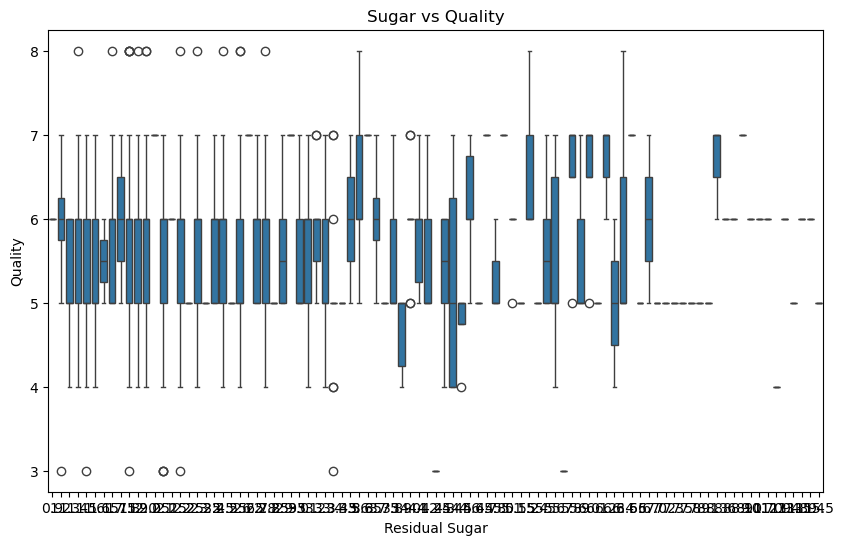

In [18]:
'''
This block plots the Sugar columns with the Quality column.
'''
#plot the data
matPlot.figure(figsize=(10, 6))
seaborn.boxplot(x='residual sugar', y='quality', data=data)
matPlot.title('Sugar vs Quality')
matPlot.xlabel('Residual Sugar')
matPlot.ylabel('Quality')
matPlot.show()

In [ ]:
'''
This block splits the cleaned dataset into training and testing data.
'''
from sklearn.model_selection import train_test_split

#display what should be the expected data modelling pre-split into training and testing data sets.
total_rows = data.shape[0]
training_data = int(0.8 * total_rows)
print(f'We have a total of {total_rows} rows of data.')
print(f'80% of {total_rows} is {training_data} which should be our testing data')
print(f'Training would be {total_rows - training_data}')

# the are our features and target variables (we exclude "Gender" column as it serves no purpose here)
features = data[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides',
'free sulfur dioxide','total sulfur dioxide', 'density', 'pH','sulphates','alcohol']]
target = data['quality']

#splits the data 80 (training) and 20 (testing)
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=42, shuffle=True)

#showing the results of the split
print('\nRESULTS OF SPLIT')
print(f'Training set shape details are: x_train = {x_train.shape}, y_train= {y_train.shape}')
print(f'Testing set shape details are: x_test = {x_test.shape}, y_train= {y_test.shape}')

#Printing the data for the first 5 rows for both training and test datasets
print("\n--- Training Set Statistics ---")
print(x_train.head())

print("\n--- Test Set Statistics ---")
print(x_test.head())


We have a total of 1599 rows of data.
80% of 1599 is 1279 which should be our testing data
Training would be 320

RESULTS OF SPLIT
Training set shape details are: x_train = (1279, 11), y_train= (1279,)
Testing set shape details are: x_test = (320, 11), y_train= (320,)

--- Training Set Statistics ---
     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
493            8.7             0.690         0.31             3.0      0.086   
354            6.1             0.210         0.40             1.4      0.066   
342           10.9             0.390         0.47             1.8      0.118   
834            8.8             0.685         0.26             1.6      0.088   
705            8.4             1.035         0.15             6.0      0.073   

     free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
493                 23.0                  81.0  1.00020  3.48       0.74   
354                 40.5                 165.0  0.99120  3.25    

In [21]:
# We calculate the meana nd stanard deviation for the training and test data to compare the model's results
train_mean = x_train.mean()
train_std = x_train.std()

test_mean = x_test.mean()
test_std = x_test.std()

# we display the mean and standard deviation to see if the results match.
print(f'The mean for the training data is {train_mean} and the standard deviation is {train_std}')
print(f'The mean for the testing data is {test_mean} and the standard deviation is {test_std}')

The mean for the training data is fixed acidity            8.323690
volatile acidity         0.530559
citric acid              0.272471
residual sugar           2.555473
chlorides                0.088448
free sulfur dioxide     15.876075
total sulfur dioxide    46.657154
density                  0.996774
pH                       3.311650
sulphates                0.660023
alcohol                 10.418100
dtype: float64 and the standard deviation is fixed acidity            1.724243
volatile acidity         0.179275
citric acid              0.195448
residual sugar           1.435790
chlorides                0.049332
free sulfur dioxide     10.313517
total sulfur dioxide    32.941962
density                  0.001856
pH                       0.154016
sulphates                0.174605
alcohol                  1.052694
dtype: float64
The mean for the testing data is fixed acidity            8.303437
volatile acidity         0.516875
citric acid              0.265000
residual sugar         

In [ ]:
# This is the start of assignment 2

In [ ]:
# Part (a) - Regression

The Root mean square error = 0.6245
The R-squared = 0.4032


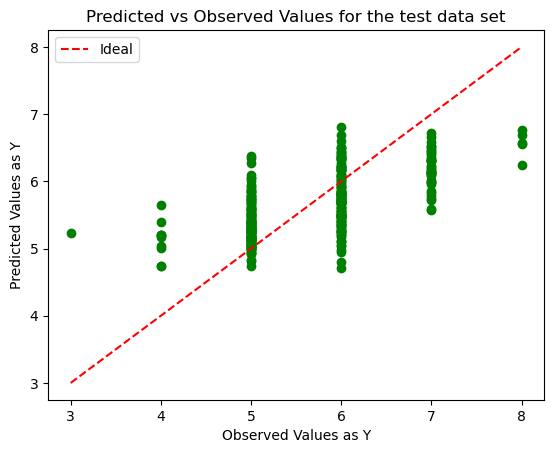

In [ ]:
# fitting multiple regression model to training set

import numpy
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

# creating a multiple leaner model object
multiple_regression = linear_model.LinearRegression()

# fitting the model to the training data
multiple_regression.fit(x_train, y_train)

# applying the model to the test data
y_predicted = multiple_regression.predict(x_test)

# Evaluating the model
print('The Root mean square error = %.4f' % numpy.sqrt(mean_squared_error(y_test, y_predicted))) 
print('The R-squared = %.4f' % r2_score(y_test, y_predicted))

# comparing the predicted values with the observed values with a line of best-fit
matPlot.scatter(y_test, y_predicted, color='green')
matPlot.title('Predicted vs Observed Values for the test data set')
matPlot.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
matPlot.xlabel('Observed Values as Y')
matPlot.ylabel('Predicted Values as Y') 
matPlot.legend()
matPlot.show() 

